step 1 --> import the necessary libraries 


In [9]:
import pandas as pd
import matplotlib.pyplot as plt

load the data 

In [10]:
df = pd.read_csv('netflix_titles.csv')

clean the data 

In [26]:
# If a row has a missing value in any of these 5 specific columns,
#  the entire row is dropped. If a row has missing values in other 
# columns (e.g., a missing director or description), 
# but these 5 columns are complete, the row will be kept.
df = df.dropna(subset=['type','release_year','rating','country','duration'])


In [27]:
type_counts=df['type'].value_counts()
print(type_counts)

type
Movie      5687
TV Show    2283
Name: count, dtype: int64


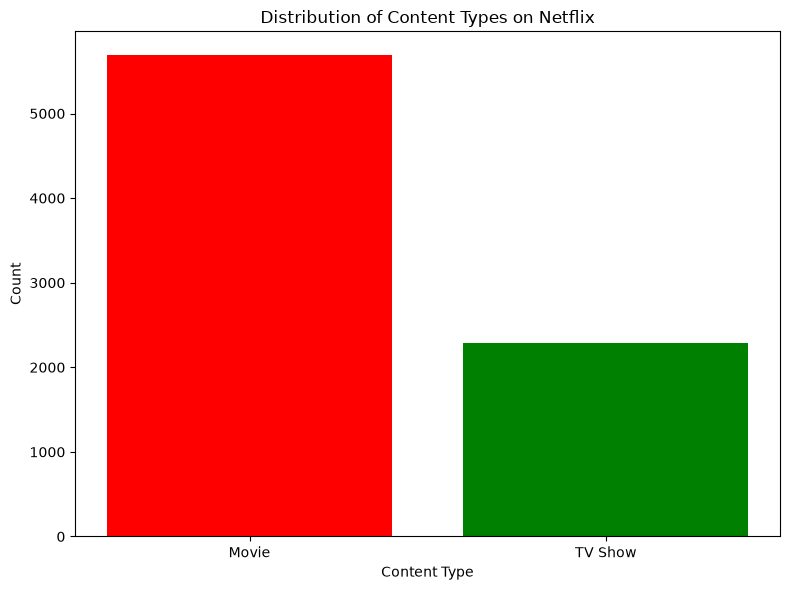

In [28]:
plt.figure(figsize=(8,6))
plt.bar(type_counts.index, type_counts.values , color=['red', 'green'])
plt.title('Distribution of Content Types on Netflix')
plt.xlabel('Content Type')
plt.ylabel('Count')
plt.tight_layout()
plt.savefig('movie_vs_tvshows.png')
plt.show()

For rating

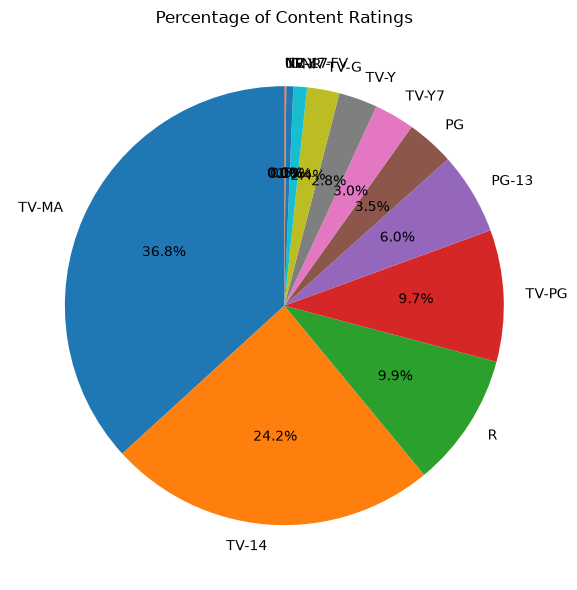

In [30]:
rating_counts = df['rating'].value_counts()
plt.figure(figsize=(8,6))
plt.pie(rating_counts, labels=rating_counts.index, autopct='%1.1f%%', startangle=90)
plt.title('Percentage of Content Ratings')
plt.tight_layout()
plt.savefig('pie_rating.png')
plt.show()

# movie filtering 

movie_df['duration_int'] = movie_df['duration'].str.replace(' min','').astype(int)

The Problem: In raw Netflix data, runtimes are stored as text (strings) like "90 min" or "120 min". You can't perform math or plot a numerical distribution on words.

The Fix: 
1. .str.replace(' min', '') strips away the text part " min", leaving just the raw characters "90" or "120".

2. .astype(int) converts those text digits into actual mathematical integers (90, 120).

3. It saves these numbers into a brand new column named 'duration_int'.

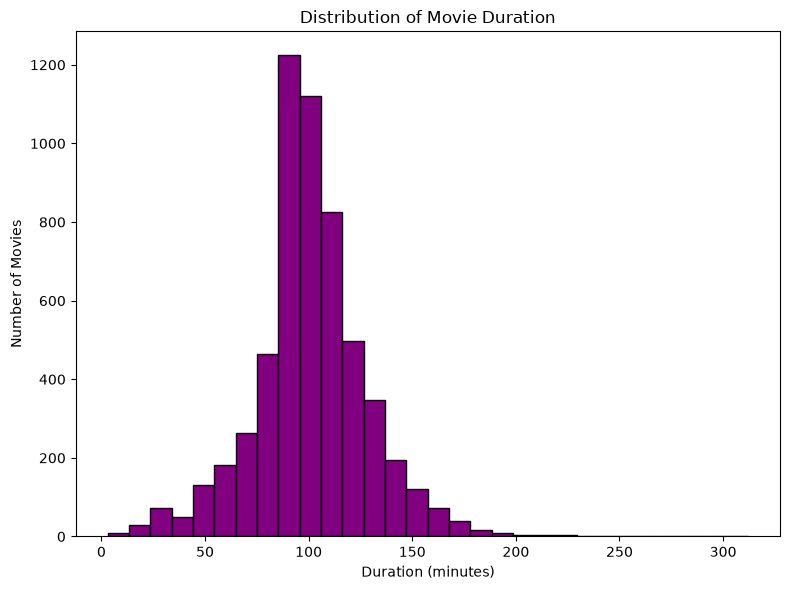

In [31]:
movie_df = df[df["type"] == "Movie"].copy()

movie_df["duration_int"] = movie_df["duration"].str.replace(" min", "").astype(int)


# Distribution of Movie Runtimes (Histogram)
plt.figure(figsize=(8, 6))
plt.hist(movie_df["duration_int"], bins=30, color="purple", edgecolor="black")
plt.title("Distribution of Movie Duration")  # Fixed typo here
plt.xlabel("Duration (minutes)")
plt.ylabel("Number of Movies")
plt.tight_layout()
plt.savefig("movie_duration_histogram.png")
plt.show()

release count 

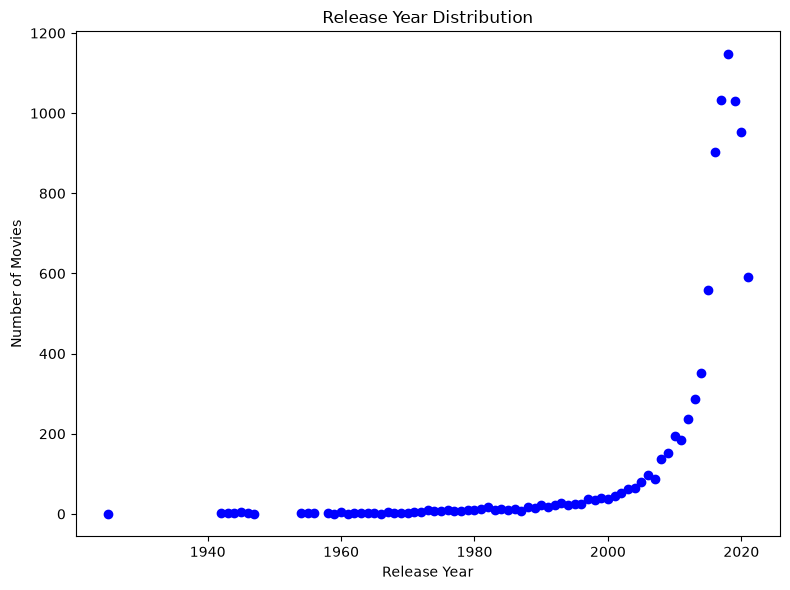

In [11]:
try:
    df
except NameError:
    df = pd.read_csv('netflix_titles.csv')
    df = df.dropna(subset=['type', 'release_year', 'rating', 'country', 'duration'])

release_counts = df['release_year'].value_counts().sort_index()
plt.figure(figsize=(8,6))
plt.scatter(release_counts.index, release_counts.values, color='blue')
plt.title("Release Year Distribution")
plt.xlabel("Release Year")
plt.ylabel("Number of Movies")
plt.tight_layout()
plt.savefig("movie_release_year_distribution.png")
plt.show()

In [21]:
country_counts = df['country'].value_counts()
print(country_counts)

country
United States                                    2818
India                                             972
United Kingdom                                    419
Japan                                             245
South Korea                                       199
                                                 ... 
Russia, Spain                                       1
Croatia, Slovenia, Serbia, Montenegro               1
Japan, Canada                                       1
United States, France, South Korea, Indonesia       1
United Arab Emirates, Jordan                        1
Name: count, Length: 748, dtype: int64


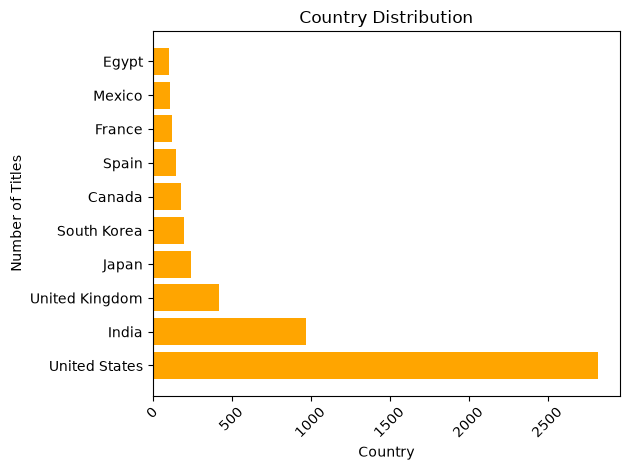

In [25]:
plt.barh(country_counts.index[:10], country_counts.values[:10], color='orange')
plt.title("Country Distribution")
plt.xlabel("Country")
plt.ylabel("Number of Titles")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("movie_country_distribution.png")
plt.show()

movie by year 

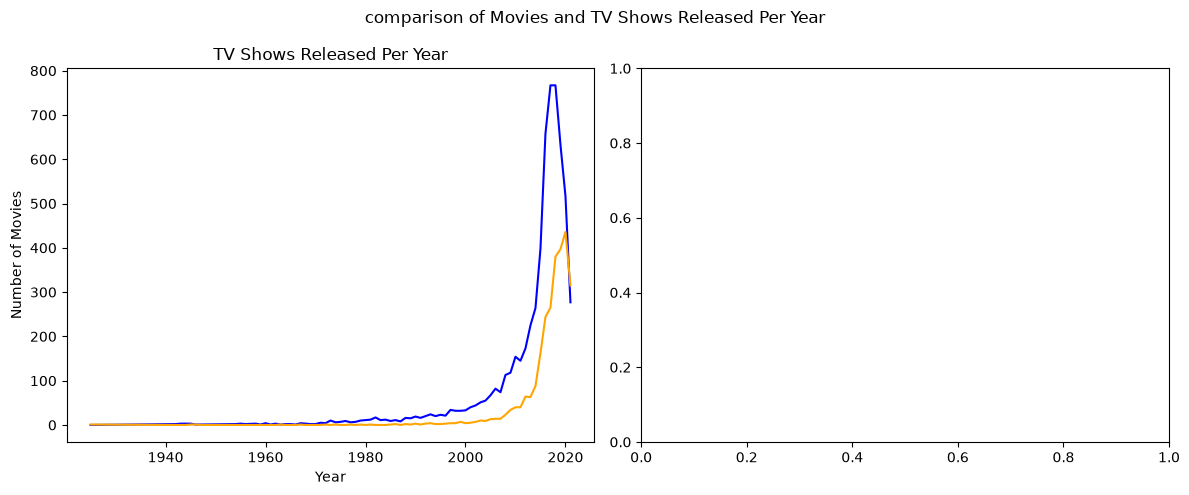

In [24]:
content_by_year = df.groupby(['release_year', 'type']).size().unstack().fillna(0)

fig, ax = plt.subplots(1,2, figsize=(12,5))

#first subplot:movies
ax[0].plot(content_by_year.index, content_by_year['Movie'], color='blue')
ax[0].set_title('Movies Released Per Year')
ax[0].set_xlabel('Year')
ax[0].set_ylabel('Number of Movies')

#second subplot:TV Shows
ax[0].plot(content_by_year.index, content_by_year['TV Show'], color='orange')
ax[0].set_title('TV Shows Released Per Year')
ax[0].set_xlabel('Year')
ax[0]. set_ylabel('Number of Movies')

fig.suptitle("comparison of Movies and TV Shows Released Per Year")
plt.tight_layout()
plt.savefig("comparison_movies_tvshows.png")
plt.show()